In [ ]:
# Hosted D2L setup: fetch the exact helper module used to build this notebook.
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import PackageNotFoundError, version
import importlib.util, os, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'requests', 'scipy', 'pillow', 'regex', 'jax', 'jaxlib', 'flax', 'optax', 'orbax-checkpoint', 'tensorflow', 'protobuf', 'ml-dtypes', 'safetensors', 'tiktoken']
imports = {'pillow': 'PIL', 'orbax-checkpoint': 'orbax', 'protobuf': 'google.protobuf', 'ml-dtypes': 'ml_dtypes'}
pinned = {'jax': ('0.10.2', 'jax==0.10.2', 'jax[cuda12]==0.10.2', 'exact'), 'jaxlib': ('0.10.2', 'jaxlib==0.10.2', 'jaxlib==0.10.2', 'exact'), 'flax': ('0.12.7', 'flax==0.12.7', 'flax==0.12.7', 'exact'), 'optax': ('0.2.8', 'optax==0.2.8', 'optax==0.2.8', 'exact'), 'orbax-checkpoint': ('0.12.0', 'orbax-checkpoint==0.12.0', 'orbax-checkpoint==0.12.0', 'exact'), 'safetensors': ('0.8.0', 'safetensors==0.8.0', 'safetensors==0.8.0', 'exact'), 'tiktoken': ('0.13.0', 'tiktoken==0.13.0', 'tiktoken==0.13.0', 'exact')}
fallbacks = {'tensorflow': 'tensorflow==2.21.0', 'protobuf': 'protobuf==7.34.1', 'ml-dtypes': 'ml-dtypes==0.5.4'}
device = os.environ.get("D2L_HOSTED_DEVICE", "auto").lower()
if device not in ("auto", "cpu", "gpu"):
    raise ValueError(f"Invalid D2L_HOSTED_DEVICE={device!r}")
if device == "auto":
    try:
        gpu = (Path("/dev/nvidia0").exists() or
               subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=5).returncode == 0)
    except (FileNotFoundError, subprocess.SubprocessError):
        gpu = False
else:
    gpu = device == "gpu"
if not gpu:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
tensorflow_version = None
if 'jax' in ("tensorflow", "jax"):
    try:
        tensorflow_version = version("tensorflow")
    except PackageNotFoundError:
        pass
# Colab's CPU image currently carries a CUDA-enabled TensorFlow wheel. Its
# first ordinary tensor operation probes CUDA and emits an error-level cuInit
# diagnostic. JAX notebooks also use TensorFlow for data loading, so overlay
# the matching CPU build in both CPU variants. Keep the provider's
# ``tensorflow`` distribution metadata: other preinstalled Colab packages
# depend on that distribution name, while both wheels expose the same module.
if not gpu and 'jax' in ("tensorflow", "jax"):
    try:
        tensorflow_cpu_version = version("tensorflow-cpu")
    except PackageNotFoundError:
        tensorflow_cpu_version = None
    if (tensorflow_version is not None and
            tensorflow_cpu_version != tensorflow_version):
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "--no-deps",
            f"tensorflow-cpu=={tensorflow_version}",
        ])
if "tf-keras" in fallbacks and tensorflow_version is not None:
    fallbacks["tf-keras"] = f"tf-keras=={tensorflow_version}"
missing = []
for package in required:
    if package in pinned:
        wanted, cpu_requirement, gpu_requirement, match = pinned[package]
        requirement = gpu_requirement if gpu else cpu_requirement
        try:
            installed = version(package)
        except PackageNotFoundError:
            installed = None
        actual = (installed.split("+", 1)[0]
                  if installed is not None and match == "public" else installed)
        if actual != wanted:
            missing.append(requirement)
    elif importlib.util.find_spec(imports.get(package, package)) is None:
        missing.append(fallbacks.get(package, package))
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

mismatched = []
for package, (wanted, _, _, match) in pinned.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    actual = (installed.split("+", 1)[0]
              if installed is not None and match == "public" else installed)
    if actual != wanted:
        mismatched.append(f"{package}={installed!r} (expected {wanted})")
if mismatched:
    raise RuntimeError("Hosted runtime setup failed: " + ", ".join(mismatched))

root = Path(".d2l-hosted") / "8cd319b4f2187b6b29bb69603a96460fc325a975"
package = root / "d2l"
package.mkdir(parents=True, exist_ok=True)
base = "https://raw.githubusercontent.com/smolix/d2l-neu/8cd319b4f2187b6b29bb69603a96460fc325a975/d2l"
for name in ('__init__.py', 'jax.py'):
    target = package / name
    if not target.exists():
        urlretrieve(f"{base}/{name}", target)
if str(root.resolve()) not in sys.path:
    sys.path.insert(0, str(root.resolve()))
pythonpath = os.environ.get("PYTHONPATH", "").split(os.pathsep)
if str(root.resolve()) not in pythonpath:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [str(root.resolve()), *[entry for entry in pythonpath if entry]]
    )


# Generation and the KV Cache

The `generate` method of that section was left deliberately naive:
every new token reruns the full forward pass over the whole history. This
section measures that waste, eliminates it, and then studies what the fix
costs. The fix is the *KV cache*: because causal attention never lets the
past depend on the future, the keys and values of every token already
generated are final the moment they are computed, and can simply be stored.
Caching makes the dominant dense-layer work linear in the generated length
— attention itself still reads the whole growing cache at every step, so
its cumulative cost stays quadratic, a term that is real but subdominant at
the sizes we run — and it converts a compute problem into a *memory*
problem, so the second half of this section is about the bill. We derive
the cache-size formula and check it against the allocator, see why
generating tokens is bound by memory
bandwidth while reading a prompt is bound by arithmetic, and then shrink
the cache three ways: sharing keys and values across heads (MQA and GQA),
compressing them to a low-rank latent (the idea behind MLA), and bounding
the context with a sliding window, which works only together with a
counterintuitive companion, the *attention sink*. Everything runs on the
`d2l.GPT` class of the previous section, including the real GPT-2, which
supplies the phenomena that our one-minute character models are too small
to show.

In [1]:
%matplotlib inline
from d2l import jax as d2l
from flax import nnx
import jax
from jax import numpy as jnp
import math
import optax
from safetensors import numpy as safetensors_numpy
import tiktoken
from tiktoken.load import data_gym_to_mergeable_bpe_ranks
import time

## From Recompute to Cache

Start with the accounting. A forward pass of a model with $N$ parameters
over $t$ tokens costs about $2Nt$ floating-point operations — every
parameter participates in one multiply–add per token — plus the attention
score work of that section, which is quadratic in $t$
but subdominant at the model sizes we run here. Naive generation calls
this forward pass once per token, over a history that grows by one each
step: producing $T$ tokens after a prompt costs roughly
$\sum_{t} 2Nt \approx N T^2$ operations, quadratic in the length of the
text, for logits of which all but the last row are thrown away.

Almost all of that work is literally repeated. At step $t$ the model
needs, in every layer, the attention output for one new query
$\mathbf{q}_t$ against the keys and values $\mathbf{k}_{1..t},
\mathbf{v}_{1..t}$. The causal mask guarantees that positions
$1, \ldots, t-1$ never see position $t$, so their hidden states — and
therefore their keys and values — are the same at step $t$ as they were at
step $t-1$. The fix writes itself: keep a per-layer buffer of all keys and
values computed so far, and at each step run the transformer on *one*
token, appending its $\mathbf{k}_t, \mathbf{v}_t$ to the buffer and
attending against the whole of it. the figure contrasts the
two schedules. The cost of a cached step is one forward pass over a single
token, about $2N$ operations, independent of $t$.

![One decoding step at context length $t$. Naive generation recomputes every key, value, and score row of the prefix and then uses only the last row. With a KV cache, the past keys and values are read from memory, and the step computes a single new key, value, and score row.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-transformers-kv-cache.svg)

### The Cached Forward Pass

Two details need care. First, positions: RoPE rotates queries and keys by
their *absolute* position, so the attention step must know where in the
sequence its tokens sit — the `_rope` helper of `d2l.GPT` always counted
from zero, and we now need an `offset`. (A learned position table needs
the same offset, one line in the model forward.) Second, the interface:
the step receives only the *new* tokens plus the cache, instead of the
whole history.

Growing a tensor by one slot per step would be poison for JAX: every new
length is a new shape, and every new shape triggers a fresh XLA
compilation. The naive `generate` of that section already solved
this problem once, by allocating the token buffer at its final size and
overwriting it. The cache follows the same discipline, and it is exactly
how production JAX serving works: preallocate K and V buffers of shape
`(layers, batch, max_len, heads, head_dim)`, write each step's keys and
values into their slots with `dynamic_update_slice`, and mask attention
so that queries only see filled positions. The function compiles once
for the prompt shape and once for the single-token step, and the decode
loop then reuses that compilation at every step — static shapes are not a
limitation here but the feature that makes the compiled path possible.

In [2]:
def rope(x, offset=0):
    """Rotary rotation of x at absolute positions offset, offset+1, ..."""
    d = x.shape[-1]
    pos = offset + jnp.arange(x.shape[1])
    inv_freq = 10000.0 ** (-jnp.arange(0, d, 2) / d)
    theta = pos[:, None] * inv_freq[None, :]
    cos = jnp.cos(theta)[:, None, :]  # broadcast over heads
    sin = jnp.sin(theta)[:, None, :]
    x1, x2 = x[..., 0::2], x[..., 1::2]
    return jnp.stack([x1 * cos - x2 * sin,
                      x1 * sin + x2 * cos], -1).reshape(x.shape)

def init_cache(model, batch_size, max_len):
    """Preallocated K and V buffers, one slab per layer."""
    attn = model.blks[0].attention
    head_dim = attn.W_o.in_features // attn.num_heads
    shape = (len(model.blks), batch_size, max_len, attn.num_heads, head_dim)
    return jnp.zeros(shape), jnp.zeros(shape)

The model-level step walks the blocks the way `d2l.GPT.forward` does,
handing each block's attention its cache; a `generate_cached` then
repeats the sampling loop of that section, prefixed by a single
prefill call, with each subsequent step feeding in one token.

In [3]:
@nnx.jit
def cached_forward(model, ks, vs, X, t):
    """Logits for the last of the new tokens X at positions t, t+1, ...;
    writes their keys and values into the cache slots at those positions."""
    B, T = X.shape
    H = model.token_emb(X)
    if model.pos == 'learned':
        H = H + model.pos_emb(t + jnp.arange(T))
    mask = (jnp.arange(ks.shape[2])[None, :]
            <= (t + jnp.arange(T))[:, None])[None, None]
    for i, blk in enumerate(model.blks):  # pre-norm arrangement
        attn, Y = blk.attention, blk.norm1(H)
        q, k, v = jnp.split(attn.W_qkv(Y), 3, axis=-1)
        q, k, v = (u.reshape(B, T, attn.num_heads, -1) for u in (q, k, v))
        if attn.rope:
            q, k = rope(q, t), rope(k, t)
        # Callers must keep t + T <= max_len: an out-of-range write does
        # not fail here -- dynamic_update_slice clamps its start index
        # silently. (t is traced under jit, so generate_cached asserts.)
        ks = jax.lax.dynamic_update_slice(ks, k[None], (i, 0, t, 0, 0))
        vs = jax.lax.dynamic_update_slice(vs, v[None], (i, 0, t, 0, 0))
        Y = jax.nn.dot_product_attention(q, ks[i], vs[i], mask=mask)
        H = H + attn.W_o(Y.reshape(B, T, -1))
        H = H + blk.ffn(blk.norm2(H))
    return model.token_emb.attend(model.norm(H))[:, -1], ks, vs

@d2l.add_to_class(d2l.GPT)
def generate_cached(self, prefix, num_tokens, seed=0, temperature=1.0,
                    top_k=None):
    """Sample as generate does, but never recompute the prefix."""
    assert len(prefix) + num_tokens <= self.max_len, 'cache overflow'
    ks, vs = init_cache(self, 1, self.max_len)
    logits, ks, vs = cached_forward(self, ks, vs,
                                    jnp.asarray(prefix)[None], jnp.array(0))
    ids, key = list(prefix), jax.random.key(seed)
    for t in range(len(prefix), len(prefix) + num_tokens):
        l = logits[0] / temperature
        if top_k is not None:
            l = jnp.where(l < jnp.sort(l)[-top_k], -jnp.inf, l)
        key, sub = jax.random.split(key)
        ids.append(int(jax.random.categorical(sub, l)))
        logits, ks, vs = cached_forward(self, ks, vs,
                                        jnp.asarray([[ids[-1]]]),
                                        jnp.array(t))
    return ids

### Same Logits, Measured

A cache is an optimization, and the first duty of an optimization is to
change nothing. We compare the cached path against the full forward pass
on both positional schemes: prefill sixteen tokens, then decode one at a
time, and stack the resulting logits against those of a single
whole-sequence call.

In [4]:
with jax.default_matmul_precision('highest'):
    for pos in ('rope', 'learned'):
        model = d2l.GPT(vocab_size=97, num_hiddens=128, num_heads=4,
                        num_blks=3, pos=pos, rngs=nnx.Rngs(0))
        model.eval()
        x = jax.random.randint(jax.random.key(1), (1, 48), 0, 97)
        full = model(x)
        ks, vs = init_cache(model, 1, 64)
        logits, ks, vs = cached_forward(model, ks, vs, x[:, :16],
                                        jnp.array(0))
        outs = [logits]
        for t in range(16, 48):
            logits, ks, vs = cached_forward(model, ks, vs, x[:, t:t + 1],
                                            jnp.array(t))
            outs.append(logits)
        err = jnp.abs(jnp.stack([o[0] for o in outs]) - full[0, 15:]).max()
        print(f'{pos}: max |full - cached| = {err:.2e}')

rope: max |full - cached| = 9.39e-07


learned: max |full - cached| = 8.34e-07


(We pin matrix multiplications to full fp32 for the comparison, as in
that section: by default they run in TF32 on this
hardware, which perturbs the two computation orders differently at the
$10^{-4}$ level and would obscure the fact that they are the same
computation.)

Agreement to floating-point rounding. Now the payoff. We time a single
generation step at growing context length on a GPT-2-sized instance of
our class — 124M parameters, untrained, since arithmetic does not care
what the weights are. The naive step is a full forward pass over $n$
tokens; the cached step is a forward pass over one token against a cache
of length $n-1$.

123.6M parameters


n=  512: naive  31.27 ms/token, cached 11.53 ms/token


n= 1024: naive  14.83 ms/token, cached 11.30 ms/token


n= 2048: naive  42.23 ms/token, cached 12.44 ms/token


n= 4096: naive  76.04 ms/token, cached 12.12 ms/token


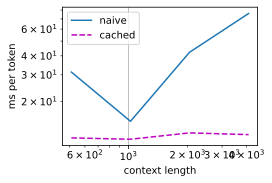

In [5]:
model = d2l.GPT(vocab_size=50257, num_hiddens=768, num_heads=12,
                num_blks=12, max_len=4096, rngs=nnx.Rngs(0))
model.eval()
n_params = sum(p.size for p in jax.tree.leaves(nnx.state(model, nnx.Param)))
print(f'{n_params / 1e6:.1f}M parameters')

@nnx.jit
def naive_step(model, buf, t):
    """The step inside the naive generate: a full forward pass."""
    return model(buf)[0, t - 1]

def timeit(f, reps=10):
    f().block_until_ready()         # warm up (and compile)
    t0 = time.time()
    for _ in range(reps):
        f().block_until_ready()
    return (time.time() - t0) / reps

lengths, t_naive, t_cached = [512, 1024, 2048, 4096], [], []
for n in lengths:
    buf = jnp.zeros((1, n), dtype=jnp.int32)
    t_naive.append(
        timeit(lambda: naive_step(model, buf, jnp.array(n - 1))) * 1e3)
    ks, vs = init_cache(model, 1, n)
    one = jnp.zeros((1, 1), dtype=jnp.int32)
    t_cached.append(timeit(lambda: cached_forward(
        model, ks, vs, one, jnp.array(n - 1))[0]) * 1e3)
    print(f'n={n:5d}: naive {t_naive[-1]:6.2f} ms/token, '
          f'cached {t_cached[-1]:5.2f} ms/token')
d2l.plot(lengths, [t_naive, t_cached], 'context length', 'ms per token',
         legend=['naive', 'cached'], xscale='log', yscale='log')

Read the plot from the right. At long contexts the naive step grows
roughly linearly with $n$, as $2Nn$ arithmetic says it must, while the
cached step stays flat; at a context of four thousand tokens the gap in
our runs is about a factor of five, and it doubles with every further
doubling of context. At short contexts the two curves *merge* — below
about a thousand tokens this model is so small that a step of either kind
is dominated by launching a dozen blocks' worth of GPU kernels, not by
computing. The cache is not a magic constant factor; it removes a term
that grows with context, and pays off precisely when that term dominates.
End to end, the effect on `generate` is what the per-step curve promises:

In [6]:
prefix = list(range(3584))
for name, gen in (('naive ', model.generate),
                  ('cached', model.generate_cached)):
    t0 = time.time()
    gen(prefix, 256, seed=0)
    dt = time.time() - t0
    print(f'{name}: 256 tokens after a 3584-token prompt: {dt:4.1f}s '
          f'= {256 / dt:5.1f} tokens/s')

naive : 256 tokens after a 3584-token prompt: 24.5s =  10.5 tokens/s


cached: 256 tokens after a 3584-token prompt:  8.8s =  29.2 tokens/s


Several times faster at this prompt length — each timing includes one XLA
compilation for its shapes, so the steady-state gap is larger still, as
the per-step curve above shows. Production serving systems generate this
way; "time to first token" is our prefill call, and "tokens per second"
is the cached decode loop.

## The Memory Bill

The cache is not free; it is a rent paid in the scarcest resource a GPU
has. Each of the $n_\textrm{layers}$ layers stores one key and one value
vector of dimension $n_\textrm{kv} \cdot d_\textrm{head}$ per token, so a
batch of $b$ sequences of length $n$ holds

$$
\textrm{cache bytes} \;=\; 2 \cdot n_\textrm{layers} \cdot n_\textrm{kv}
\cdot d_\textrm{head} \cdot n \cdot b \cdot (\textrm{bytes per element}),
$$

where the leading 2 counts K and V and $n_\textrm{kv}$ is the number of
key-value heads (equal to the number of query heads, for now: the next
section breaks that equality). For our GPT-2-sized model in fp32 that is
$2 \cdot 12 \cdot 12 \cdot 64 \cdot 4$ bytes $= 72$ KiB per token: at a
context of 4096 the cache holds 288 MiB, more than half the size of the
124M-parameter model itself. Scale the formula up to a modern deployment
— dozens of layers, contexts in the hundreds of thousands, batches of
concurrent users — and the cache, not the weights, is what fills the
accelerator; the exercises make this concrete for a 70B model. Formulas
should be checked, not trusted:

In [7]:
ks, vs = init_cache(model, 1, 4096)
formula = 2 * 12 * 12 * 64 * 4096 * 4
print(f'cache buffers: {(ks.nbytes + vs.nbytes) / 2**20:.0f} MiB, '
      f'formula says {formula / 2**20:.0f} MiB')

cache buffers: 288 MiB, formula says 288 MiB


In JAX the check is almost circular, and that is itself the lesson: the
fixed-size discipline forces the entire bill to be allocated up front, so
the equation is not a prediction about hidden allocator
behavior but the literal size of two arrays you created. A serving
configuration that does not fit fails at initialization, not mid-request.

### Prefill Is Compute-Bound, Decode Is Memory-Bound

Why obsess over the size of a buffer that merely *sits* in memory?
Because at generation time it does not sit — it moves. Every decoded
token must read every cached key and value once, and, more importantly,
must read *every parameter of the model* once: that is what "a forward
pass over one token" means. The useful lens is *arithmetic intensity*:
FLOPs performed per byte of memory traffic. A decode step performs about
$2N$ FLOPs and moves at least the $4N$ bytes of fp32 weights plus the
cache, an intensity below one FLOP per byte. A prefill over $n$ tokens
performs $2Nn$ FLOPs against the *same* weight traffic (the weights are
read once and reused for every token in the batch of positions), an
intensity roughly $n$ times higher. A modern GPU is balanced at far
higher intensities (an RTX 4090 delivers up to about $83$ TFLOP/s of
fp32 compute but only about $1$ TB/s of memory bandwidth, a ridge near
80 FLOPs per byte), so prefill lands comfortably compute-bound while
single-stream decode cannot even in principle keep the arithmetic units
busy: it is a memory-bandwidth workload
[@Pope.Douglas.Chowdhery.ea.2023]. The two phases of one `generate`
call live on opposite sides of the roofline.

In [8]:
N = n_params
x = jnp.zeros((1, 2048), dtype=jnp.int32)
ks, vs = init_cache(model, 1, 2048)
t_prefill = timeit(
    lambda: cached_forward(model, ks, vs, x, jnp.array(0))[0], reps=5)
one = jnp.zeros((1, 1), dtype=jnp.int32)
t_decode = timeit(
    lambda: cached_forward(model, ks, vs, one, jnp.array(2047))[0])
print(f'prefill: 2048 tokens in {t_prefill * 1e3:4.0f} ms = '
      f'{2048 / t_prefill:6.0f} tokens/s')
print(f'decode:  one token in {t_decode * 1e3:6.2f} ms = '
      f'{1 / t_decode:6.0f} tokens/s')
cache = 2 * 12 * 12 * 64 * 2048 * 4
flops, moved = 2 * N, 4 * N + cache
print(f'decode intensity: {flops / 1e6:.0f} MFLOP / {moved / 1e6:.0f} MB '
      f'= {flops / moved:.1f} FLOP/byte (GPU ridge is near 80)')
print(f'prefill intensity: about {flops * 2048 / moved:.0f} FLOP/byte')
print(f'bandwidth ceiling for decode: about '
      f'{1.0e12 / moved:.0f} tokens/s')

prefill: 2048 tokens in   34 ms =  60455 tokens/s
decode:  one token in  14.44 ms =     69 tokens/s
decode intensity: 247 MFLOP / 645 MB = 0.4 FLOP/byte (GPU ridge is near 80)
prefill intensity: about 784 FLOP/byte
bandwidth ceiling for decode: about 1550 tokens/s


The measurement is blunt: this model reads a two-thousand-token prompt at
tens of thousands of tokens per second and then generates at about a
hundred — three orders of magnitude apart, on identical hardware, running
identical layers. Note also the gap between our measured decode rate and
the bandwidth ceiling the arithmetic promises: a Python loop that
launches every kernel of every block one token at a time pays overheads
that production engines eliminate with compiled decode loops and CUDA
graphs, and the ceiling is what they climb toward. The structural point
survives sloppy plumbing, though: decode speed is set by *bytes that must
move per token*, weights plus cache, so every byte shaved off the cache
is decode speed, longer feasible contexts, or more concurrent users. That
is why the rest of this section is about making the cache smaller.

## Sharing Keys and Values across Heads

Look again at the equation: the factor $n_\textrm{kv}$ is
the number of key-value heads, and nothing in the attention mechanism
forces it to equal the number of query heads. Queries do the asking;
keys and values are the library being consulted. *Multi-query attention*
(MQA) keeps all $H$ query heads but a single shared key-value head
[@Shazeer.2019], shrinking the cache by a factor of $H$ at a
usually slight cost in quality. *Grouped-query attention* (GQA)
interpolates: $H_{kv}$
key-value heads, each serving a contiguous group of $H / H_{kv}$ query
heads [@Ainslie.Lee-Thorp.Jong.ea.2023]. the figure shows
the sharing patterns. GQA with $H_{kv} = H/4$ to $H/8$ is close to the
universal choice of current open models — Llama 3 runs 32 query heads
against 8 key-value heads, Mistral 7B the same
[@Grattafiori.Dubey.Jauhri.ea.2024; @Jiang.Sablayrolles.Mensch.ea.2023].

![Query heads and the key-value heads they read. Multi-head attention gives every query head its own key-value head; grouped-query attention shares one per group of query heads; multi-query attention shares a single one across all of them. The cache scales with the number of key-value heads.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-transformers-gqa.svg)

### A Pluggable Implementation

`GQAAttention` below generalizes the causal attention of
that section: `W_q` still produces $H$ query heads, but `W_k` and
`W_v` produce only $H_{kv}$ heads, and the fused kernel broadcasts each
key-value head across its query group (in PyTorch via `enable_gqa`; the
JAX kernel accepts grouped shapes natively). We keep the
`(queries, keys, values, valid_lens)` call shape of
`d2l.MultiHeadAttention`, so the class drops into
`d2l.TransformerBlock`'s `attn_factory` hook — the seam
that section built for exactly this purpose — and,
with `rope=True`, into `d2l.GPT`. Setting $H_{kv} = H$ recovers standard
multi-head attention exactly.

In [9]:
class GQAAttention(nnx.Module):
    """Causal multi-head attention with num_kv_heads shared KV heads."""
    def __init__(self, num_hiddens, num_heads, num_kv_heads, bias=False,
                 rope=False, causal=True, rngs=None):
        rngs = nnx.Rngs(0) if rngs is None else rngs
        assert num_hiddens % num_heads == 0
        assert num_heads % num_kv_heads == 0
        self.num_heads, self.num_kv_heads = num_heads, num_kv_heads
        self.head_dim = num_hiddens // num_heads
        self.rope, self.causal = rope, causal
        self.W_q = nnx.Linear(num_hiddens, num_hiddens, use_bias=bias,
                              rngs=rngs)
        self.W_k = nnx.Linear(num_hiddens, num_kv_heads * self.head_dim,
                              use_bias=bias, rngs=rngs)
        self.W_v = nnx.Linear(num_hiddens, num_kv_heads * self.head_dim,
                              use_bias=bias, rngs=rngs)
        self.W_o = nnx.Linear(num_hiddens, num_hiddens, use_bias=bias,
                              rngs=rngs)

    def _rope(self, x):  # the rotation of d2l.GPT, kept self-contained
        d = x.shape[-1]
        pos = jnp.arange(x.shape[1], dtype=jnp.float32)
        inv_freq = 10000.0 ** (-jnp.arange(0, d, 2) / d)
        theta = pos[:, None] * inv_freq[None, :]
        cos = jnp.cos(theta)[:, None, :]
        sin = jnp.sin(theta)[:, None, :]
        x1, x2 = x[..., 0::2], x[..., 1::2]
        return jnp.stack([x1 * cos - x2 * sin,
                          x1 * sin + x2 * cos], -1).reshape(x.shape)

    def __call__(self, queries, keys, values, valid_lens=None):
        B, T, D = queries.shape
        q = self.W_q(queries).reshape(B, T, self.num_heads, -1)
        k = self.W_k(keys).reshape(B, -1, self.num_kv_heads, self.head_dim)
        v = self.W_v(values).reshape(B, -1, self.num_kv_heads,
                                     self.head_dim)
        if self.rope:
            q, k = self._rope(q), self._rope(k)
        mask, causal = None, self.causal
        if valid_lens is not None:      # mask padding (and causality)
            S = k.shape[1]
            if valid_lens.ndim == 1:
                valid_lens = jnp.broadcast_to(valid_lens[:, None], (B, T))
            mask = (jnp.arange(S)[None, None, :]
                    < valid_lens[:, :, None])[:, None]
            if causal:
                i, j = jnp.arange(T)[:, None], jnp.arange(S)[None, :]
                mask = mask & (j <= i + S - T)
            causal = False
        Y = jax.nn.dot_product_attention(q, k, v, mask=mask,
                                         is_causal=causal)
        return self.W_o(Y.reshape(B, T, -1)), None

It honors the block contract, and its parameter count records where the
saving comes from: `W_k` and `W_v` shrink with $H_{kv}$ (attention
parameters go from $4d^2$ toward $2d^2$), while the cache line of
the equation shrinks in proportion.

In [10]:
X = jnp.ones((2, 10, 256))
blk = d2l.TransformerBlock(
    256, num_heads=8,
    attn_factory=lambda rngs: GQAAttention(256, 8, 2, causal=False,
                                           rngs=rngs))
d2l.check_shape(blk(X, jnp.array([7, 4])), X.shape)
for G in (8, 4, 2, 1):
    attn = GQAAttention(256, 8, G)
    n = sum(p.size for p in jax.tree.leaves(nnx.state(attn, nnx.Param)))
    print(f'H_kv={G}: {n:6d} parameters, '
          f'cache {2 * G * 32 * 4:4d} bytes per token per layer')

H_kv=8: 262144 parameters, cache 2048 bytes per token per layer


H_kv=4: 196608 parameters, cache 1024 bytes per token per layer
H_kv=2: 163840 parameters, cache  512 bytes per token per layer


H_kv=1: 147456 parameters, cache  256 bytes per token per layer


### Cache Against Quality

What does the sharing cost in modeling power? We train the
that section configuration on the character-level Time Machine at
every group count from $H_{kv} = 8$ (full multi-head) down to $1$ (MQA),
swapping the attention in each block after construction. Because the
validation loss of this small model bottoms out within a few hundred
steps and then climbs into memorization (that section), we compare
models at their *best* validation loss over a fixed 600-step budget.

In [11]:
data = d2l.TimeMachine(batch_size=64, num_steps=128, tokenization='char',
                       num_train=100000, num_val=3000)

@nnx.jit
def batch_loss(model, X, Y):
    logits = model(X)
    return optax.softmax_cross_entropy_with_integer_labels(
        logits.reshape(-1, logits.shape[-1]), Y.reshape(-1)).mean()

def val_loss(model, data):
    model.eval()
    losses = [float(batch_loss(model, jnp.asarray(X), jnp.asarray(Y)))
              for X, Y in data.val_dataloader()]
    model.train()
    return sum(losses) / len(losses)

for G in (8, 4, 2, 1):
    rngs = nnx.Rngs(0)
    lm = d2l.GPT(len(data.vocab), num_hiddens=256, num_heads=8,
                 num_blks=6, rngs=rngs)
    for blk in lm.blks:
        blk.attention = GQAAttention(256, 8, G, rope=True, rngs=rngs)
    optimizer = nnx.Optimizer(lm, optax.adamw(1e-3, weight_decay=0.0),
                              wrt=nnx.Param)
    best = float('inf')
    for chunk in range(6):
        d2l.train_lm(lm, data, optimizer, 100)
        best = min(best, val_loss(lm, data))
    print(f'H_kv={G}: best validation loss {best:.2f}, '
          f'cache {2 * 6 * G * 32 * 4 / 1024:4.1f} KiB per token')

H_kv=8: best validation loss 1.55, cache 12.0 KiB per token


H_kv=4: best validation loss 1.51, cache  6.0 KiB per token


H_kv=2: best validation loss 1.51, cache  3.0 KiB per token


H_kv=1: best validation loss 1.54, cache  1.5 KiB per token


The cache shrinks eightfold from top to bottom of the table; the loss
column does not move outside run-to-run noise (rerunning any row with a
different seed shifts it by a few hundredths, about the spread of the
whole column). At this scale the sharing costs nothing we can measure.
That conclusion would be too strong to carry to large models on our
evidence alone, but the large-scale literature reaches a similar verdict
by more careful means: full MQA costs a measurable sliver of quality,
while GQA at $H/8$ matches multi-head attention in the ablations of
@Ainslie.Lee-Thorp.Jong.ea.2023 — and an existing multi-head
checkpoint can be *uptrained* into a grouped one for a small fraction of
its original compute, which is how GQA spread through the open-model
world so quickly.

## Compressing the Cache Further

Sharing heads is one axis. This closing section looks at the two other
levers deployed systems pull — compressing the *width* of each cached
token further, and bounding the *length* of what is cached — and at the
failure mode that makes the second one subtle. Our minute-trained
character models are too small to exhibit these phenomena, so we probe
the real GPT-2, reloading it exactly as in that section (weights
and tokenizer files are already pinned in `d2l.DATA_HUB`), along with the
raw text of *The Time Machine* as a 1024-token evaluation passage.

In [12]:
HF_URL = 'https://huggingface.co/openai-community/gpt2/resolve/main/'
d2l.DATA_HUB['gpt2-weights'] = (
    HF_URL + 'model.safetensors',
    '89a76996d7c6ee89b86618a265483aab73e61d50')
d2l.DATA_HUB['gpt2-merges'] = (
    HF_URL + 'merges.txt', '396d4d8ec90cb02f4d56e049e0e4add868bcd943')
d2l.DATA_HUB['gpt2-encoder'] = (
    HF_URL + 'vocab.json', 'f0223209235343bc067d7da838328bced8085ae1')
enc = tiktoken.Encoding(
    'gpt2', explicit_n_vocab=50257,
    pat_str=d2l.BPETokenizer.GPT2_PATTERN,
    mergeable_ranks=data_gym_to_mergeable_bpe_ranks(
        d2l.download('gpt2-merges', '../data/gpt2'),
        d2l.download('gpt2-encoder', '../data/gpt2')),
    special_tokens={'<|endoftext|>': 50256})

gpt2 = d2l.GPT(vocab_size=50257, num_hiddens=768, num_heads=12,
               num_blks=12, max_len=1024, pos='learned', norm='layer',
               act='gelu', pre_norm=True, bias=True)
weights = safetensors_numpy.load_file(
    d2l.download('gpt2-weights', '../data/gpt2'))
gpt2.token_emb.embedding[...] = jnp.asarray(weights['wte.weight'])
gpt2.pos_emb.embedding[...] = jnp.asarray(weights['wpe.weight'])
gpt2.norm.scale[...] = jnp.asarray(weights['ln_f.weight'])
gpt2.norm.bias[...] = jnp.asarray(weights['ln_f.bias'])
for i, blk in enumerate(gpt2.blks):
    for norm, key in ((blk.norm1, f'h.{i}.ln_1'),
                      (blk.norm2, f'h.{i}.ln_2')):
        norm.scale[...] = jnp.asarray(weights[key + '.weight'])
        norm.bias[...] = jnp.asarray(weights[key + '.bias'])
    for linear, key in ((blk.attention.W_qkv, f'h.{i}.attn.c_attn'),
                        (blk.attention.W_o, f'h.{i}.attn.c_proj'),
                        (blk.ffn.W_1, f'h.{i}.mlp.c_fc'),
                        (blk.ffn.W_2, f'h.{i}.mlp.c_proj')):
        linear.kernel[...] = jnp.asarray(weights[key + '.weight'])
        linear.bias[...] = jnp.asarray(weights[key + '.bias'])
gpt2.eval()

fname = d2l.download(d2l.DATA_URL + 'timemachine.txt', '../data',
                     '090b5e7e70c295757f55df93cb0a180b9691891a')
ids = enc.encode(open(fname).read())[:1024]
x = jnp.asarray(ids)[None]
print(f'{len(ids)} tokens of The Time Machine')

1024 tokens of The Time Machine


Each experiment below changes only what happens *inside* attention, so
one helper suffices: a forward pass that walks GPT-2's blocks exactly as
the class does, but lets us substitute the attention computation per
block. First a sanity check that the helper with stock attention
reproduces the model, and a baseline loss on the second half of the
passage (positions 512 onward, so every evaluated token has a long
history to draw on).

In [13]:
def forward_blocks(model, X, attn_fn):
    """GPT-2 forward with a pluggable attention computation per block."""
    H = model.token_emb(X) + model.pos_emb(jnp.arange(X.shape[1]))
    for i, blk in enumerate(model.blks):
        A, Y = blk.attention, blk.norm1(H)
        B, T, D = Y.shape
        q, k, v = (u.reshape(B, T, A.num_heads, -1)
                   for u in jnp.split(A.W_qkv(Y), 3, axis=-1))
        H = H + A.W_o(attn_fn(q, k, v, i).reshape(B, T, D))
        H = H + blk.ffn(blk.norm2(H))
    return model.token_emb.attend(model.norm(H))

def tail_loss(logits):
    """Mean per-token loss on the second half of the passage."""
    return optax.softmax_cross_entropy_with_integer_labels(
        logits[0, 512:-1], x[0, 513:]).mean()

stock = lambda q, k, v, i: jax.nn.dot_product_attention(q, k, v,
                                                        is_causal=True)
logits = forward_blocks(gpt2, x, stock)
print(f'helper vs stock forward: max deviation '
      f'{jnp.abs(logits - gpt2(x)).max():.1e}')
full = tail_loss(logits)
print(f'full attention: loss {full:.2f}, perplexity {jnp.exp(full):.0f}')

helper vs stock forward: max deviation 0.0e+00


full attention: loss 3.58, perplexity 36


### Low-Rank Keys and Values

GQA shrinks the cache by storing fewer key-value heads. A different bet:
keep all heads, but suppose the concatenated key and value vectors of a
token — for GPT-2, $2 \times 768 = 1536$ numbers — do not really span
1536 dimensions, and store only their coordinates in some
lower-dimensional subspace. That is the idea behind *multi-head latent
attention* (MLA), the mechanism DeepSeek built its V2 and V3 models
around [@DeepSeek-AI.2024]: a trained projection compresses each
token's keys and values jointly into one latent vector (rank 512, versus
tens of thousands of raw KV dimensions, in DeepSeek-V2), the cache
stores only the latent, and per-head keys and values are reconstructed
by trained up-projections at read time.

We can test the load-bearing assumption — that realized keys and values
are approximately low-rank — directly on GPT-2. In each layer we take
the actual K and V matrices of our passage, replace them by their best
rank-$r$ approximation (via SVD, jointly across the concatenated KV
width of 1536), and run the model with every layer so truncated. This
uses an oracle factorization computed on the very sequence being
evaluated, so it is an upper bound on what a fixed trained projection
could do; MLA's contribution is making the projection trainable, and
handling the one real obstacle: RoPE's position-dependent rotation does
not commute with a shared down-projection, which MLA solves by carrying
a small separate rotary component per token. None of that machinery is
needed to check the premise:

In [14]:
def lowrank_kv(r):
    def attn_fn(q, k, v, i):
        B, T, H, hd = k.shape
        KV = jnp.concatenate([k.reshape(T, -1), v.reshape(T, -1)], axis=1)
        U, S, Vh = jnp.linalg.svd(KV, full_matrices=False)
        KVr = (U[:, :r] * S[:r]) @ Vh[:r]     # best rank-r approximation
        kr = KVr[:, :H * hd].reshape(1, T, H, hd)
        vr = KVr[:, H * hd:].reshape(1, T, H, hd)
        return jax.nn.dot_product_attention(q, kr, vr, is_causal=True)
    return attn_fn

for r in (256, 128):
    loss = tail_loss(forward_blocks(gpt2, x, lowrank_kv(r)))
    print(f'rank {r} of 1536 ({1536 // r}x smaller cache): '
          f'loss {loss:.2f}, perplexity {jnp.exp(loss):.0f}')

rank 256 of 1536 (6x smaller cache): loss 3.49, perplexity 33


rank 128 of 1536 (12x smaller cache): loss 3.66, perplexity 39


At rank 256 — a cache six times smaller — the loss on this passage is
indistinguishable from the full model's (the tiny difference between the
two numbers is single-passage noise, and we make nothing of it). At rank
128 the model measurably worsens but remains coherent. The premise
holds: what attention actually reads back from its cache lives in a far
lower-dimensional space than the cache stores. The six-fold saving is
notional here — our SVD basis is fitted to this very passage and would
itself need storing — and that is exactly what MLA supplies: one
projection, trained once and shared globally, that the model learns to
write through, pushing the compression much further than after-the-fact
truncation can.

### A Window Needs a Sink

The remaining lever is length: cap the cache at the last $w$ tokens,
evicting the oldest as generation proceeds, and memory is bounded
forever — the rolling-buffer form of the sliding-window attention of
that section. Before evicting anything, it is worth
asking where a trained model actually *sends* its attention. We measure
the average weight that GPT-2's queries (from position 64 on) place on
the single first token of the sequence:

In [15]:
masses = []
def watch(q, k, v, i):
    qh, kh, vh = (u.transpose(0, 2, 1, 3) for u in (q, k, v))
    scores = qh @ kh.swapaxes(-1, -2) / math.sqrt(q.shape[-1])
    j = jnp.arange(scores.shape[-1])
    scores = jnp.where(j[None, :] > j[:, None],
                       jnp.finfo(scores.dtype).min, scores)
    alpha = jax.nn.softmax(scores, axis=-1)
    masses.append(float(alpha[..., 64:, 0].mean()))
    return (alpha @ vh).transpose(0, 2, 1, 3)

forward_blocks(gpt2, x, watch)
print('mean attention weight on token 0 (uniform would be ~0.003):')
print('  '.join(f'layer {i}: {m:.2f}' for i, m in enumerate(masses)))

mean attention weight on token 0 (uniform would be ~0.003):
layer 0: 0.00  layer 1: 0.01  layer 2: 0.11  layer 3: 0.30  layer 4: 0.32  layer 5: 0.51  layer 6: 0.46  layer 7: 0.57  layer 8: 0.48  layer 9: 0.48  layer 10: 0.45  layer 11: 0.34


From the middle of the stack upward, GPT-2 parks a *third to a half* of
its entire attention mass on the first token — a hundred times more than
an even spread would give it, and mostly regardless of what that token
is. This is the *attention sink* [@Xiao.Tian.Chen.ea.2024]: softmax
must hand out probability mass that sums to one, a head that currently
has nothing to retrieve needs somewhere harmless to put it, and training
converges on the one position every query can always see. The first
token becomes the designated dumping ground — an observation about the
attention *weights*; how much its value vector actually contributes to
the output is a separate quantity, which we have not measured.

Now the trap springs. Evict that token, as a naive rolling buffer of the
most recent $w$ entries would, and every head's dumping ground vanishes:
the discarded mass is renormalized onto tokens the head actively chose
not to attend to. StreamingLLM's fix is embarrassingly small — keep the
first few tokens in the cache forever, alongside the sliding window
[@Xiao.Tian.Chen.ea.2024]. We reproduce both the failure and the
fix, evaluating our passage with attention restricted to a 256-token
window plus a varying number of retained *sink tokens*:

In [16]:
j = jnp.arange(x.shape[1])
causal = j[None, :] <= j[:, None]
window = causal & (j[:, None] - j[None, :] < 256)
for nsink in (0, 1, 4):
    mask = window | (causal & (j[None, :] < nsink))
    loss = tail_loss(forward_blocks(
        gpt2, x, lambda q, k, v, i: jax.nn.dot_product_attention(
            q, k, v, mask=mask[None, None])))
    print(f'window 256 + {nsink} sink tokens: loss {loss:.2f}, '
          f'perplexity {jnp.exp(loss):.0f}')
print(f'full attention:            loss {full:.2f}, '
      f'perplexity {jnp.exp(full):.0f}')

window 256 + 0 sink tokens: loss 8.25, perplexity 3842
window 256 + 1 sink tokens: loss 3.86, perplexity 47


window 256 + 4 sink tokens: loss 3.76, perplexity 43
full attention:            loss 3.58, perplexity 36


The numbers are dramatic. Windowed attention alone destroys the model:
perplexity explodes from the mid-thirties into the thousands, on text
where every evaluated token has its entire 256-token window available —
the damage is not lost context but the lost sink. Restoring a *single*
initial token recovers almost everything, and four sink tokens land
within a fraction of a nat of full attention. (Our mask-based experiment
keeps original position indices; a real rolling buffer also has to
handle positions carefully as entries are evicted, which is an
exercise.) The lesson generalizes beyond eviction: the sink is a
structural fact about softmax attention in trained transformers.
Modern designs increasingly build it in on purpose: gpt-oss ships an
explicit learned sink logit per head in its sliding-window layers
[@OpenAI.2025], which frees the first token from double duty.

### The Cache-Relief Map

The techniques of this section slot into one map, organized by which
factor of the equation they attack. GQA and MLA shrink the
*width* of each cached token: fewer key-value heads, or a low-rank
latent in place of the full vectors. Sliding windows (with their sinks)
bound the *length*, at the price of genuinely forgetting the far past.
The linear attention of that section removes the
cache altogether, collapsing the entire past into a fixed-size recurrent
state — that is its real selling point, constant-memory generation — and
the hybrid stacks of that section interleave a few
full-attention layers into a mostly-linear model so that most layers pay
no cache at all while a few retain exact recall. Beyond the cache
proper, the decode-side bandwidth arithmetic of this section is also
what *speculative decoding* exploits, drafting several tokens cheaply
and verifying them in one prefill-priced pass
[@Leviathan.Kalman.Matias.2023]. The roofline economics behind that
arithmetic are made precise in that section; the systems-level
story of speculative decoding and the serving engines around it belongs
to the Language Models part.

## Summary

Naive generation reruns the full forward pass per token, quadratic in
the length of the text; since causality freezes every past token's keys
and values, storing them makes the dominant dense-layer work linear
(attention still reads the growing cache, a cumulative quadratic that
stays subdominant at our sizes). The cached step is
mostly plumbing — a per-layer K/V buffer and a position offset for RoPE
(in JAX, a preallocated fixed-shape buffer with index writes, so one
compiled function serves every step) — and it leaves the logits
unchanged to floating-point rounding while decoding several times faster
at long contexts. The price is memory: $2 \cdot n_\textrm{layers} \cdot
n_\textrm{kv} \cdot d_\textrm{head} \cdot n \cdot b$ elements, verified
against the allocator, and the cache moves on every step. Counting FLOPs
against bytes shows prefill compute-bound and decode memory-bound, which
is why cache bytes are the currency of generation speed. GQA spends that
insight on head sharing: our sweep from 8 key-value heads to 1 shrank
the cache eightfold with best validation loss flat to within seed noise,
matching the large-scale ablations. MLA compresses width instead, and
the oracle version of its premise checks out on GPT-2 (a rank-256
truncation of the 1536-wide KV cache leaves the loss unchanged on our
passage). Bounding length with a sliding window fails catastrophically
if it evicts the *attention sink* (the first token, where trained
softmax attention parks a third to a half of its weight), and
keeping even one sink token restores the model; gpt-oss builds the sink
in as a learned logit. Linear attention removes the cache entirely, and
hybrid stacks interleave the two regimes.

## Exercises

1. Work out the KV cache of Llama-2-70B, which uses 80 layers, 64 query
   heads of dimension 128, and GQA with 8 key-value heads, storing the
   cache in 16-bit precision. How many bytes per token? At what context
   length does a single sequence's cache reach the size of the weights
   (140 GB in fp16)? Redo both numbers for the same model without GQA
   (64 key-value heads) and for MQA (1 key-value head).
2. Break the cache deliberately: remove the `offset` from the cached
   RoPE path, so decoded tokens are rotated as if they sat at position
   zero, and rerun the correctness check. How large is the logit
   deviation, and why does it grow with the length of the prefix? What
   is the corresponding bug for the `pos='learned'` scheme?
3. Our decode measurement ran a batch of one. Extend `generate_cached`
   to a batch of prompts of equal length and measure tokens per second
   at batch sizes 1, 4, 16, and 64 at a fixed context. Explain the shape
   of the curve with the arithmetic-intensity argument: which bytes are
   read once per *step* and which once per *sequence*?
4. The PyTorch implementation grows the cache by `torch.cat`, copying
   the whole buffer every step; the JAX one preallocates and writes into
   slots, but hands the jitted function fresh buffer copies unless the
   arguments are donated. Fix either one: preallocate in PyTorch (write
   into a slice of a `max_len` buffer), or pass `donate_argnums` for the
   cache arguments in JAX. Measure the per-step latency at context 4096
   before and after your fix.
5. Give `GQAAttention` a `forward_step` in the style of this section, so
   that the cache stores only the $H_{kv}$ key-value heads. Verify
   correctness against the full forward pass, and confirm that measured
   cache memory shrinks by $H / H_{kv}$.
6. Implement a true rolling buffer: cap the per-layer cache at the 4
   sink entries plus the most recent $w - 4$, evicting the rest as
   generation proceeds past $w$ tokens. Decide what position index a
   retained entry should keep (consider both the `'rope'` and
   `'learned'` schemes), state your choice, and check the model's loss
   on a long passage against the mask-based experiment of this section.